# A04 — One Strong Result: Partition Granularity and FlashAttention Activation

**CISC-727: Advanced Research Explorations (ARE) - I**

**Author:** Kenneth Peter Fernandes | Harrisburg University of Science and Technology

**Platform:** Kaggle Notebooks — 2x NVIDIA T4 GPUs

---

## Overview

- **A02 Gap:** FlashAttention is well-benchmarked on single GPUs, but its interaction with multi-GPU communication overhead (DDP vs FSDP) is underexplored.
- **A03 Pilot Finding:** FlashAttention showed no speedup because ViT-Small patch_size=16 on CIFAR-10 produces only 5 tokens (5x5 attention matrix fits entirely in SRAM).
- **A04 Lever:** Partition granularity change — patch_size 16 → 4 (5 tokens → 65 tokens)
- **Hypothesis:** With 65 tokens, FlashAttention's tiling should activate, producing a measurable speedup over standard attention that was absent at 5 tokens.

## Experiment Design

| Config | Run ID | patch_size | Seq Length | Attention | Parallelization | Hardware |
|--------|--------|-----------|------------|-----------|-----------------|----------|
| Baseline (std attn) | R1-baseline-std | 16 | 5 | math | DDP (2x T4) | Kaggle PCIe |
| Baseline (flash attn) | R1-baseline-flash | 16 | 5 | flash | DDP (2x T4) | Kaggle PCIe |
| Variant (std attn) | R2-variant-std | 4 | 65 | math | DDP (2x T4) | Kaggle PCIe |
| Variant (flash attn) | R2-variant-flash | 4 | 65 | flash | DDP (2x T4) | Kaggle PCIe |

All runs: batch_size=64/GPU, 100 steps, 10 warmup, seed=42, float32, Adam lr=1e-3, 3 repetitions each

## 1. Environment Setup

In [13]:
# Platform: Kaggle Notebooks — GPU T4 x2

import os
import time
import json
import random
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import DataLoader, DistributedSampler
import torchvision
import torchvision.transforms as transforms

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU count: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
        props = torch.cuda.get_device_properties(i)
        print(f"    Memory: {props.total_memory / 1e9:.1f} GB")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU count: 2
  GPU 0: Tesla T4
    Memory: 15.6 GB
  GPU 1: Tesla T4
    Memory: 15.6 GB


## 2. Constants and Configuration

In [14]:
# ============================================================
# Constants (held identical across ALL runs)
# ============================================================
SEED = 42
BATCH_SIZE = 64       # per GPU
NUM_STEPS = 100
WARMUP_STEPS = 10     # excluded from timing
NUM_REPETITIONS = 3
LEARNING_RATE = 0.001
NUM_CLASSES = 10      # CIFAR-10
IMG_SIZE = 32

# ViT-Small architecture (constant across runs)
VIT_EMBED_DIM = 384
VIT_NUM_HEADS = 6
VIT_NUM_LAYERS = 12

# ============================================================
# The ONE lever: patch_size
# ============================================================
BASELINE_PATCH_SIZE = 16  # A03 baseline: (32/16)^2 + 1 = 5 tokens
VARIANT_PATCH_SIZE = 4    # A04 variant:  (32/4)^2  + 1 = 65 tokens

baseline_seq_len = (IMG_SIZE // BASELINE_PATCH_SIZE) ** 2 + 1
variant_seq_len = (IMG_SIZE // VARIANT_PATCH_SIZE) ** 2 + 1
print(f"Baseline: patch_size={BASELINE_PATCH_SIZE}, seq_len={baseline_seq_len}")
print(f"Variant:  patch_size={VARIANT_PATCH_SIZE},  seq_len={variant_seq_len}")

# Results storage
RESULTS_DIR = "/kaggle/working/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

Baseline: patch_size=16, seq_len=5
Variant:  patch_size=4,  seq_len=65


In [15]:
import shutil

def set_seed(seed):
    """Set random seed for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def setup_cifar10():
    """Copy CIFAR-10 from Kaggle input to working directory for distributed training."""
    local_data_dir = "/kaggle/working/data"
    cifar_batch_dir = os.path.join(local_data_dir, "cifar-10-batches-py")
    
    if os.path.exists(cifar_batch_dir):
        print(f"CIFAR-10 already at {cifar_batch_dir}")
        return local_data_dir
    
    # Find the cifar-10-batches-py folder under /kaggle/input
    kaggle_input = "/kaggle/input"
    source = None
    for root, dirs, files in os.walk(kaggle_input):
        if "cifar-10-batches-py" in dirs:
            source = os.path.join(root, "cifar-10-batches-py")
            break
        if "data_batch_1" in files:
            source = root
            break
    
    if source is None:
        raise FileNotFoundError(
            "CIFAR-10 not found in /kaggle/input/. "
            "Add 'cifar-10-python' dataset via Add Input in the sidebar."
        )
    
    os.makedirs(local_data_dir, exist_ok=True)
    shutil.copytree(source, cifar_batch_dir)
    print(f"Copied CIFAR-10 from {source} to {cifar_batch_dir}")
    return local_data_dir


def get_cifar10_dataloader(batch_size, distributed=False, rank=0, world_size=1):
    """Create CIFAR-10 train dataloader."""
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])
    dataset = torchvision.datasets.CIFAR10(
        root=CIFAR_DATA_DIR, train=True, download=False, transform=transform
    )
    sampler = None
    if distributed:
        sampler = DistributedSampler(dataset, num_replicas=world_size, rank=rank, shuffle=True)
    loader = DataLoader(
        dataset, batch_size=batch_size, shuffle=(sampler is None),
        sampler=sampler, num_workers=2, pin_memory=True, drop_last=True
    )
    return loader


# Setup CIFAR-10 data
CIFAR_DATA_DIR = setup_cifar10()

# Quick validation
_ = get_cifar10_dataloader(1)
print("CIFAR-10 loaded successfully.")

Copied CIFAR-10 from /kaggle/input/datasets/kenferns93/cifar-10-python/cifar-10-batches-py to /kaggle/working/data/cifar-10-batches-py
CIFAR-10 loaded successfully.


In [16]:
def set_seed(seed):
    """Set random seed for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_cifar10_dataloader(batch_size, distributed=False, rank=0, world_size=1):
    """Create CIFAR-10 train dataloader."""
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])
    dataset = torchvision.datasets.CIFAR10(
        root="/kaggle/working/data", train=True, download=True, transform=transform
    )
    sampler = None
    if distributed:
        sampler = DistributedSampler(dataset, num_replicas=world_size, rank=rank, shuffle=True)
    loader = DataLoader(
        dataset, batch_size=batch_size, shuffle=(sampler is None),
        sampler=sampler, num_workers=2, pin_memory=True, drop_last=True
    )
    return loader


# Pre-download CIFAR-10 so distributed workers don't race
_ = get_cifar10_dataloader(1)
print("CIFAR-10 downloaded.")

CIFAR-10 downloaded.


## 4. ViT-Small Model Definition

Same architecture as A03, but `patch_size` is now a parameter (16 or 4).

In [17]:
DIST_SCRIPT = "/kaggle/working/dist_train_a04.py"

dist_script_content = '''
import os
import sys
import json
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import DataLoader, DistributedSampler
import torchvision
import torchvision.transforms as transforms

# ---- Constants ----
SEED = 42
BATCH_SIZE = 64
NUM_STEPS = 100
WARMUP_STEPS = 10
LEARNING_RATE = 0.001
IMG_SIZE = 32
EMBED_DIM = 384
NUM_HEADS = 6
NUM_LAYERS = 12
NUM_CLASSES = 10

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def get_cifar10_dataloader(batch_size, rank, world_size):
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])
    # Data already copied to /kaggle/working/data by the notebook
    dataset = torchvision.datasets.CIFAR10(
        root="/kaggle/working/data", train=True, download=False, transform=transform
    )
    sampler = DistributedSampler(dataset, num_replicas=world_size, rank=rank, shuffle=True)
    loader = DataLoader(
        dataset, batch_size=batch_size, shuffle=False,
        sampler=sampler, num_workers=2, pin_memory=True, drop_last=True
    )
    return loader

# ---- Model ----
class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, embed_dim, in_channels=3):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches + 1, embed_dim))

    def forward(self, x):
        B = x.shape[0]
        x = self.proj(x).flatten(2).transpose(1, 2)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_embed
        return x

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, use_flash=False):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Linear(embed_dim * 4, embed_dim),
        )
        self.use_flash = use_flash

    def forward(self, x):
        normed = self.norm1(x)
        if self.use_flash:
            with torch.nn.attention.sdpa_kernel(torch.nn.attention.SDPBackend.FLASH_ATTENTION):
                attn_out, _ = self.attn(normed, normed, normed)
        else:
            with torch.nn.attention.sdpa_kernel(torch.nn.attention.SDPBackend.MATH):
                attn_out, _ = self.attn(normed, normed, normed)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x

class ViTSmall(nn.Module):
    def __init__(self, img_size=32, patch_size=16, embed_dim=384,
                 num_heads=6, num_layers=12, num_classes=10, use_flash=False):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, embed_dim)
        self.blocks = nn.Sequential(
            *[TransformerBlock(embed_dim, num_heads, use_flash) for _ in range(num_layers)]
        )
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        x = self.blocks(x)
        x = self.norm(x[:, 0])
        x = self.head(x)
        return x

# ---- Training ----
def main():
    rank = int(os.environ["LOCAL_RANK"])
    world_size = int(os.environ["WORLD_SIZE"])

    dist.init_process_group("nccl")
    torch.cuda.set_device(rank)
    device = torch.device(f"cuda:{rank}")

    # Parse args: patch_size, use_flash, output_file
    patch_size = int(sys.argv[1])
    use_flash = sys.argv[2] == "1"
    output_file = sys.argv[3]

    set_seed(SEED + rank)

    seq_len = (IMG_SIZE // patch_size) ** 2 + 1
    if rank == 0:
        print(f"Config: patch_size={patch_size}, seq_len={seq_len}, "
              f"flash={use_flash}, world_size={world_size}")

    model = ViTSmall(
        img_size=IMG_SIZE, patch_size=patch_size, embed_dim=EMBED_DIM,
        num_heads=NUM_HEADS, num_layers=NUM_LAYERS, num_classes=NUM_CLASSES,
        use_flash=use_flash
    ).to(device)

    model = DDP(model, device_ids=[rank])

    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()
    loader = get_cifar10_dataloader(BATCH_SIZE, rank, world_size)

    model.train()
    step_times = []
    fwd_times = []
    bwd_times = []
    losses = []
    data_iter = iter(loader)

    for step in range(NUM_STEPS):
        try:
            images, labels = next(data_iter)
        except StopIteration:
            data_iter = iter(loader)
            images, labels = next(data_iter)

        images, labels = images.to(device), labels.to(device)

        # CUDA event timing
        start_event = torch.cuda.Event(enable_timing=True)
        fwd_end = torch.cuda.Event(enable_timing=True)
        bwd_end = torch.cuda.Event(enable_timing=True)
        end_event = torch.cuda.Event(enable_timing=True)

        start_event.record()
        optimizer.zero_grad()

        output = model(images)
        loss = criterion(output, labels)

        fwd_end.record()

        loss.backward()

        bwd_end.record()

        optimizer.step()

        end_event.record()
        torch.cuda.synchronize()

        step_times.append(start_event.elapsed_time(end_event) / 1000.0)  # ms -> s
        fwd_times.append(start_event.elapsed_time(fwd_end) / 1000.0)
        bwd_times.append(fwd_end.elapsed_time(bwd_end) / 1000.0)
        losses.append(loss.item())

    if rank == 0:
        measured_times = step_times[WARMUP_STEPS:]
        measured_fwd = fwd_times[WARMUP_STEPS:]
        measured_bwd = bwd_times[WARMUP_STEPS:]
        measured_losses = losses[WARMUP_STEPS:]

        median_time = float(np.median(measured_times))
        median_fwd = float(np.median(measured_fwd))
        median_bwd = float(np.median(measured_bwd))
        throughput = (BATCH_SIZE * world_size) / median_time

        results = {
            "patch_size": patch_size,
            "seq_len": seq_len,
            "use_flash": use_flash,
            "median_time_per_step": median_time,
            "median_fwd_time": median_fwd,
            "median_bwd_time": median_bwd,
            "throughput": throughput,
            "final_loss": float(measured_losses[-1]),
            "all_step_times": measured_times,
        }
        with open(output_file, "w") as f:
            json.dump(results, f)

    dist.destroy_process_group()

if __name__ == "__main__":
    main()
'''

with open(DIST_SCRIPT, "w") as f:
    f.write(dist_script_content)
print(f"Wrote distributed training script to {DIST_SCRIPT}")

Wrote distributed training script to /kaggle/working/dist_train_a04.py


## 5. Distributed Training Script

Written to disk so `torchrun` can launch it across 2 GPUs.

**Key change from A03:** `patch_size` is now passed as a command-line argument.

In [18]:
DIST_SCRIPT = "/kaggle/working/dist_train_a04.py"

dist_script_content = '''
import os
import sys
import json
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import DataLoader, DistributedSampler
import torchvision
import torchvision.transforms as transforms

# ---- Constants ----
SEED = 42
BATCH_SIZE = 64
NUM_STEPS = 100
WARMUP_STEPS = 10
LEARNING_RATE = 0.001
IMG_SIZE = 32
EMBED_DIM = 384
NUM_HEADS = 6
NUM_LAYERS = 12
NUM_CLASSES = 10

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def get_cifar10_dataloader(batch_size, rank, world_size):
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])
    dataset = torchvision.datasets.CIFAR10(
        root="/kaggle/working/data", train=True, download=False, transform=transform
    )
    sampler = DistributedSampler(dataset, num_replicas=world_size, rank=rank, shuffle=True)
    loader = DataLoader(
        dataset, batch_size=batch_size, shuffle=False,
        sampler=sampler, num_workers=2, pin_memory=True, drop_last=True
    )
    return loader

# ---- Model ----
class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, embed_dim, in_channels=3):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches + 1, embed_dim))

    def forward(self, x):
        B = x.shape[0]
        x = self.proj(x).flatten(2).transpose(1, 2)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_embed
        return x

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, use_flash=False):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Linear(embed_dim * 4, embed_dim),
        )
        self.use_flash = use_flash

    def forward(self, x):
        normed = self.norm1(x)
        if self.use_flash:
            with torch.nn.attention.sdpa_kernel(torch.nn.attention.SDPBackend.FLASH_ATTENTION):
                attn_out, _ = self.attn(normed, normed, normed)
        else:
            with torch.nn.attention.sdpa_kernel(torch.nn.attention.SDPBackend.MATH):
                attn_out, _ = self.attn(normed, normed, normed)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x

class ViTSmall(nn.Module):
    def __init__(self, img_size=32, patch_size=16, embed_dim=384,
                 num_heads=6, num_layers=12, num_classes=10, use_flash=False):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, embed_dim)
        self.blocks = nn.Sequential(
            *[TransformerBlock(embed_dim, num_heads, use_flash) for _ in range(num_layers)]
        )
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        x = self.blocks(x)
        x = self.norm(x[:, 0])
        x = self.head(x)
        return x

# ---- Training ----
def main():
    rank = int(os.environ["LOCAL_RANK"])
    world_size = int(os.environ["WORLD_SIZE"])

    dist.init_process_group("nccl")
    torch.cuda.set_device(rank)
    device = torch.device(f"cuda:{rank}")

    # Parse args: patch_size, use_flash, output_file
    patch_size = int(sys.argv[1])
    use_flash = sys.argv[2] == "1"
    output_file = sys.argv[3]

    set_seed(SEED + rank)

    seq_len = (IMG_SIZE // patch_size) ** 2 + 1
    if rank == 0:
        print(f"Config: patch_size={patch_size}, seq_len={seq_len}, "
              f"flash={use_flash}, world_size={world_size}")

    model = ViTSmall(
        img_size=IMG_SIZE, patch_size=patch_size, embed_dim=EMBED_DIM,
        num_heads=NUM_HEADS, num_layers=NUM_LAYERS, num_classes=NUM_CLASSES,
        use_flash=use_flash
    ).to(device)

    model = DDP(model, device_ids=[rank])

    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()
    loader = get_cifar10_dataloader(BATCH_SIZE, rank, world_size)

    model.train()
    step_times = []
    fwd_times = []
    bwd_times = []
    losses = []
    data_iter = iter(loader)

    for step in range(NUM_STEPS):
        try:
            images, labels = next(data_iter)
        except StopIteration:
            data_iter = iter(loader)
            images, labels = next(data_iter)

        images, labels = images.to(device), labels.to(device)

        # CUDA event timing
        start_event = torch.cuda.Event(enable_timing=True)
        fwd_end = torch.cuda.Event(enable_timing=True)
        bwd_end = torch.cuda.Event(enable_timing=True)
        end_event = torch.cuda.Event(enable_timing=True)

        start_event.record()
        optimizer.zero_grad()

        output = model(images)
        loss = criterion(output, labels)

        fwd_end.record()

        loss.backward()

        bwd_end.record()

        optimizer.step()

        end_event.record()
        torch.cuda.synchronize()

        step_times.append(start_event.elapsed_time(end_event) / 1000.0)  # ms -> s
        fwd_times.append(start_event.elapsed_time(fwd_end) / 1000.0)
        bwd_times.append(fwd_end.elapsed_time(bwd_end) / 1000.0)
        losses.append(loss.item())

    if rank == 0:
        measured_times = step_times[WARMUP_STEPS:]
        measured_fwd = fwd_times[WARMUP_STEPS:]
        measured_bwd = bwd_times[WARMUP_STEPS:]
        measured_losses = losses[WARMUP_STEPS:]

        median_time = float(np.median(measured_times))
        median_fwd = float(np.median(measured_fwd))
        median_bwd = float(np.median(measured_bwd))
        throughput = (BATCH_SIZE * world_size) / median_time

        results = {
            "patch_size": patch_size,
            "seq_len": seq_len,
            "use_flash": use_flash,
            "median_time_per_step": median_time,
            "median_fwd_time": median_fwd,
            "median_bwd_time": median_bwd,
            "throughput": throughput,
            "final_loss": float(measured_losses[-1]),
            "all_step_times": measured_times,
        }
        with open(output_file, "w") as f:
            json.dump(results, f)

    dist.destroy_process_group()

if __name__ == "__main__":
    main()
'''

with open(DIST_SCRIPT, "w") as f:
    f.write(dist_script_content)
print(f"Wrote distributed training script to {DIST_SCRIPT}")

Wrote distributed training script to /kaggle/working/dist_train_a04.py


## 6. Launcher Function

In [19]:
def run_ddp(patch_size, use_flash=False):
    """Launch DDP training across 2 GPUs with specified patch_size and attention backend."""
    output_file = f"/kaggle/working/result_ps{patch_size}_flash{use_flash}.json"

    cmd = [
        "torchrun",
        "--nproc_per_node=2",
        "--master_port=12355",
        DIST_SCRIPT,
        str(patch_size),
        "1" if use_flash else "0",
        output_file,
    ]

    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"STDERR:\n{result.stderr}")
        raise RuntimeError(f"torchrun failed with exit code {result.returncode}")

    with open(output_file, "r") as f:
        results = json.load(f)

    return results

print("Launcher function ready.")

Launcher function ready.


## 7. Execute All Runs

In [20]:
# ============================================================
# Run Plan: 4 configs x 3 repetitions = 12 runs
# ============================================================
run_plan = [
    {"run_id": "R1-baseline-std",   "patch_size": BASELINE_PATCH_SIZE, "use_flash": False},
    {"run_id": "R1-baseline-flash", "patch_size": BASELINE_PATCH_SIZE, "use_flash": True},
    {"run_id": "R2-variant-std",    "patch_size": VARIANT_PATCH_SIZE,  "use_flash": False},
    {"run_id": "R2-variant-flash",  "patch_size": VARIANT_PATCH_SIZE,  "use_flash": True},
]

all_results = {}

for run in run_plan:
    run_id = run["run_id"]
    rep_results = []
    print(f"\n{'='*60}")
    print(f"Running {run_id} (patch={run['patch_size']}, flash={run['use_flash']})")
    print(f"{'='*60}")

    for rep in range(NUM_REPETITIONS):
        print(f"  Repetition {rep+1}/{NUM_REPETITIONS}...", end=" ")
        result = run_ddp(patch_size=run["patch_size"], use_flash=run["use_flash"])
        rep_results.append(result)
        print(f"median={result['median_time_per_step']:.4f}s, "
              f"throughput={result['throughput']:.1f} samples/s")

    # Aggregate across repetitions: take median of medians
    median_times = [r["median_time_per_step"] for r in rep_results]
    median_fwd = [r["median_fwd_time"] for r in rep_results]
    median_bwd = [r["median_bwd_time"] for r in rep_results]
    throughputs = [r["throughput"] for r in rep_results]

    all_results[run_id] = {
        "run_id": run_id,
        "patch_size": run["patch_size"],
        "seq_len": (IMG_SIZE // run["patch_size"]) ** 2 + 1,
        "attention": "flash" if run["use_flash"] else "math",
        "median_time": float(np.median(median_times)),
        "median_fwd": float(np.median(median_fwd)),
        "median_bwd": float(np.median(median_bwd)),
        "throughput": float(np.median(throughputs)),
        "time_std": float(np.std(median_times)),
        "all_rep_times": median_times,
    }
    print(f"  -> Aggregated: {all_results[run_id]['median_time']:.4f}s "
          f"(+/- {all_results[run_id]['time_std']:.4f}s)")

print("\nAll runs complete.")


Running R1-baseline-std (patch=16, flash=False)
  Repetition 1/3... median=0.0597s, throughput=2142.8 samples/s
  Repetition 2/3... median=0.0604s, throughput=2119.9 samples/s
  Repetition 3/3... median=0.0601s, throughput=2131.3 samples/s
  -> Aggregated: 0.0601s (+/- 0.0003s)

Running R1-baseline-flash (patch=16, flash=True)
  Repetition 1/3... median=0.0606s, throughput=2111.7 samples/s
  Repetition 2/3... median=0.0598s, throughput=2141.5 samples/s
  Repetition 3/3... median=0.0590s, throughput=2168.7 samples/s
  -> Aggregated: 0.0598s (+/- 0.0007s)

Running R2-variant-std (patch=4, flash=False)
  Repetition 1/3... median=0.2094s, throughput=611.2 samples/s
  Repetition 2/3... median=0.2209s, throughput=579.5 samples/s
  Repetition 3/3... median=0.2318s, throughput=552.1 samples/s
  -> Aggregated: 0.2209s (+/- 0.0091s)

Running R2-variant-flash (patch=4, flash=True)
  Repetition 1/3... median=0.2480s, throughput=516.2 samples/s
  Repetition 2/3... median=0.2664s, throughput=480.6 

## 8. Compute Derived Metrics

In [21]:
# ============================================================
# FlashAttention Relative Speedup (%)
# = (time_standard - time_flash) / time_standard * 100
# ============================================================

# Baseline (patch_size=16): FA speedup
t_baseline_std = all_results["R1-baseline-std"]["median_time"]
t_baseline_flash = all_results["R1-baseline-flash"]["median_time"]
fa_speedup_baseline = (t_baseline_std - t_baseline_flash) / t_baseline_std * 100

# Variant (patch_size=4): FA speedup
t_variant_std = all_results["R2-variant-std"]["median_time"]
t_variant_flash = all_results["R2-variant-flash"]["median_time"]
fa_speedup_variant = (t_variant_std - t_variant_flash) / t_variant_std * 100

print("FlashAttention Relative Speedup (%)")
print(f"  Baseline (patch_size=16, seq=5):   {fa_speedup_baseline:+.2f}%")
print(f"  Variant  (patch_size=4,  seq=65):  {fa_speedup_variant:+.2f}%")
print()
print(f"  Delta: {fa_speedup_variant - fa_speedup_baseline:+.2f} percentage points")

if abs(fa_speedup_baseline) < 5 and fa_speedup_variant > 5:
    print("\n  => Lever ACTIVATED FlashAttention benefit.")
elif abs(fa_speedup_variant) < 5:
    print("\n  => Lever did NOT activate FlashAttention benefit (still within noise).")
else:
    print("\n  => Result requires further interpretation.")

FlashAttention Relative Speedup (%)
  Baseline (patch_size=16, seq=5):   +0.48%
  Variant  (patch_size=4,  seq=65):  -16.34%

  Delta: -16.82 percentage points

  => Result requires further interpretation.


## 9. Summary Table

In [22]:
# ============================================================
# Summary Table
# ============================================================
summary_rows = []
for run_id, res in all_results.items():
    summary_rows.append({
        "Run ID": run_id,
        "patch_size": res["patch_size"],
        "Seq Len": res["seq_len"],
        "Attention": res["attention"],
        "Median Time/Step (s)": f"{res['median_time']:.4f}",
        "Throughput (samples/s)": f"{res['throughput']:.1f}",
        "Fwd Time (s)": f"{res['median_fwd']:.4f}",
        "Bwd Time (s)": f"{res['median_bwd']:.4f}",
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

           Run ID  patch_size  Seq Len Attention Median Time/Step (s) Throughput (samples/s) Fwd Time (s) Bwd Time (s)
  R1-baseline-std          16        5      math               0.0601                 2131.3       0.0189       0.0336
R1-baseline-flash          16        5     flash               0.0598                 2141.5       0.0188       0.0334
   R2-variant-std           4       65      math               0.2209                  579.5       0.0653       0.1478
 R2-variant-flash           4       65     flash               0.2570                  498.1       0.0775       0.1718


## 10. Primary Result Figure

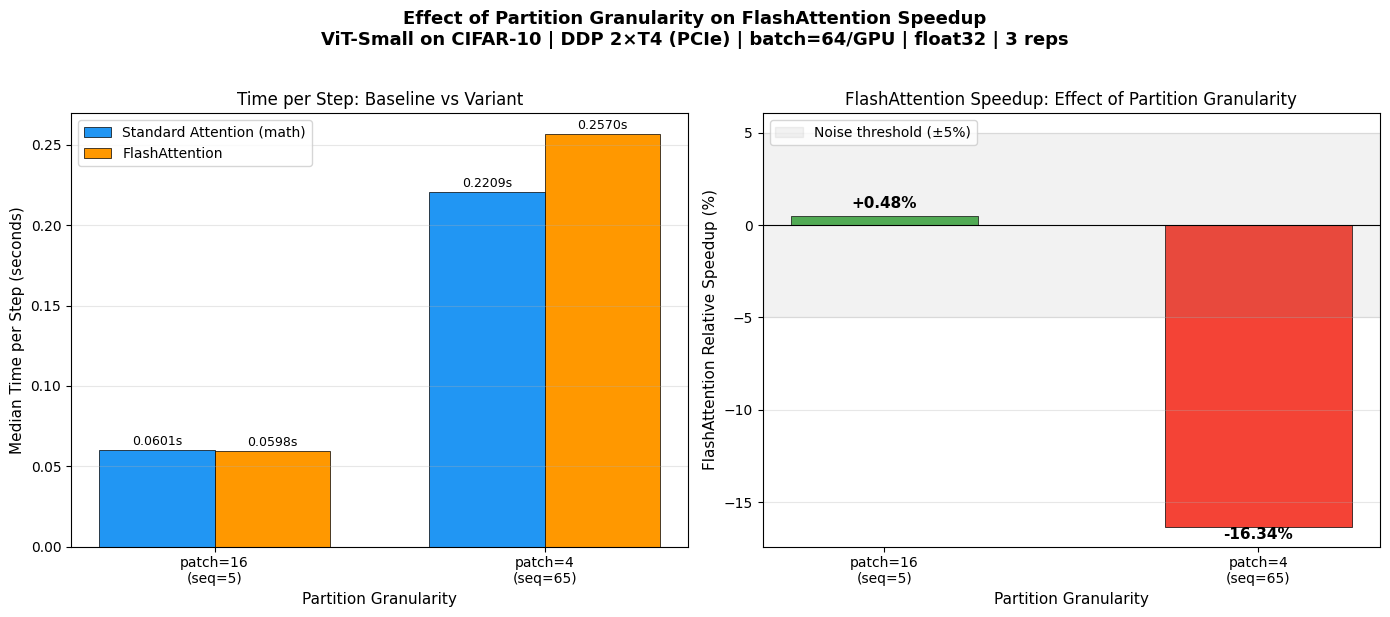

Saved to /kaggle/working/results/primary_figure.png


In [23]:
# ============================================================
# Primary Figure: Two-panel comparison
# Left:  Time per step (grouped bars)
# Right: FlashAttention relative speedup (%)
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Left Panel: Time per Step ---
labels = [f'patch=16\n(seq=5)', f'patch=4\n(seq=65)']
std_times = [t_baseline_std, t_variant_std]
flash_times = [t_baseline_flash, t_variant_flash]

x = np.arange(len(labels))
width = 0.35

bars1 = ax1.bar(x - width/2, std_times, width, label='Standard Attention (math)',
                color='#2196F3', edgecolor='black', linewidth=0.5)
bars2 = ax1.bar(x + width/2, flash_times, width, label='FlashAttention',
                color='#FF9800', edgecolor='black', linewidth=0.5)

# Add value labels on bars
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
             f'{bar.get_height():.4f}s', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
             f'{bar.get_height():.4f}s', ha='center', va='bottom', fontsize=9)

ax1.set_ylabel('Median Time per Step (seconds)', fontsize=11)
ax1.set_xlabel('Partition Granularity', fontsize=11)
ax1.set_title('Time per Step: Baseline vs Variant', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# --- Right Panel: FA Relative Speedup ---
speedups = [fa_speedup_baseline, fa_speedup_variant]
colors = ['#F44336' if s < 0 else '#4CAF50' for s in speedups]

bars3 = ax2.bar(labels, speedups, color=colors, edgecolor='black', linewidth=0.5, width=0.5)

for bar, val in zip(bars3, speedups):
    y_pos = bar.get_height() + 0.3 if val >= 0 else bar.get_height() - 0.8
    ax2.text(bar.get_x() + bar.get_width()/2., y_pos,
             f'{val:+.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.axhspan(-5, 5, alpha=0.1, color='gray', label='Noise threshold (\u00b15%)')
ax2.set_ylabel('FlashAttention Relative Speedup (%)', fontsize=11)
ax2.set_xlabel('Partition Granularity', fontsize=11)
ax2.set_title('FlashAttention Speedup: Effect of Partition Granularity', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(axis='y', alpha=0.3)

fig.suptitle(
    'Effect of Partition Granularity on FlashAttention Speedup\n'
    'ViT-Small on CIFAR-10 | DDP 2\u00d7T4 (PCIe) | batch=64/GPU | float32 | 3 reps',
    fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'primary_figure.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved to {RESULTS_DIR}/primary_figure.png")

## 11. Supporting Figure: Forward/Backward Breakdown

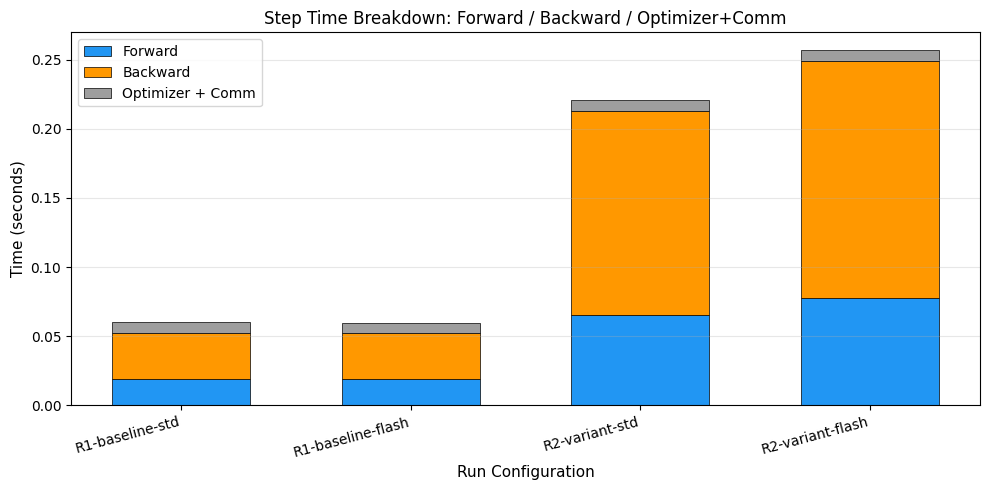

Saved to /kaggle/working/results/supporting_breakdown.png


In [24]:
# ============================================================
# Supporting Figure: Forward vs Backward time breakdown
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

run_ids = list(all_results.keys())
fwd = [all_results[r]["median_fwd"] for r in run_ids]
bwd = [all_results[r]["median_bwd"] for r in run_ids]
other = [all_results[r]["median_time"] - all_results[r]["median_fwd"] - all_results[r]["median_bwd"]
         for r in run_ids]

x = np.arange(len(run_ids))
width = 0.6

ax.bar(x, fwd, width, label='Forward', color='#2196F3', edgecolor='black', linewidth=0.5)
ax.bar(x, bwd, width, bottom=fwd, label='Backward', color='#FF9800', edgecolor='black', linewidth=0.5)
ax.bar(x, other, width, bottom=[f+b for f,b in zip(fwd, bwd)],
       label='Optimizer + Comm', color='#9E9E9E', edgecolor='black', linewidth=0.5)

ax.set_ylabel('Time (seconds)', fontsize=11)
ax.set_xlabel('Run Configuration', fontsize=11)
ax.set_title('Step Time Breakdown: Forward / Backward / Optimizer+Comm', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(run_ids, rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'supporting_breakdown.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved to {RESULTS_DIR}/supporting_breakdown.png")

## 12. Save Results

In [25]:
# ============================================================
# Save all results to CSV and JSON
# ============================================================

# Summary CSV
summary_df.to_csv(os.path.join(RESULTS_DIR, 'summary.csv'), index=False)

# Full results JSON (includes per-rep data)
save_results = {}
for run_id, res in all_results.items():
    save_results[run_id] = {
        k: v for k, v in res.items()
    }

# Add derived metrics
save_results["derived"] = {
    "fa_speedup_baseline_pct": fa_speedup_baseline,
    "fa_speedup_variant_pct": fa_speedup_variant,
    "delta_pct": fa_speedup_variant - fa_speedup_baseline,
}

with open(os.path.join(RESULTS_DIR, 'all_results.json'), 'w') as f:
    json.dump(save_results, f, indent=2)

print(f"Results saved to {RESULTS_DIR}/")
print(f"  - summary.csv")
print(f"  - all_results.json")
print(f"  - primary_figure.png")
print(f"  - supporting_breakdown.png")

Results saved to /kaggle/working/results/
  - summary.csv
  - all_results.json
  - primary_figure.png
  - supporting_breakdown.png
